# Multi-Panel Dashboards in Matplotlib

By Yusuf Oğuz

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Problem 1: Streaming Users Dashboard

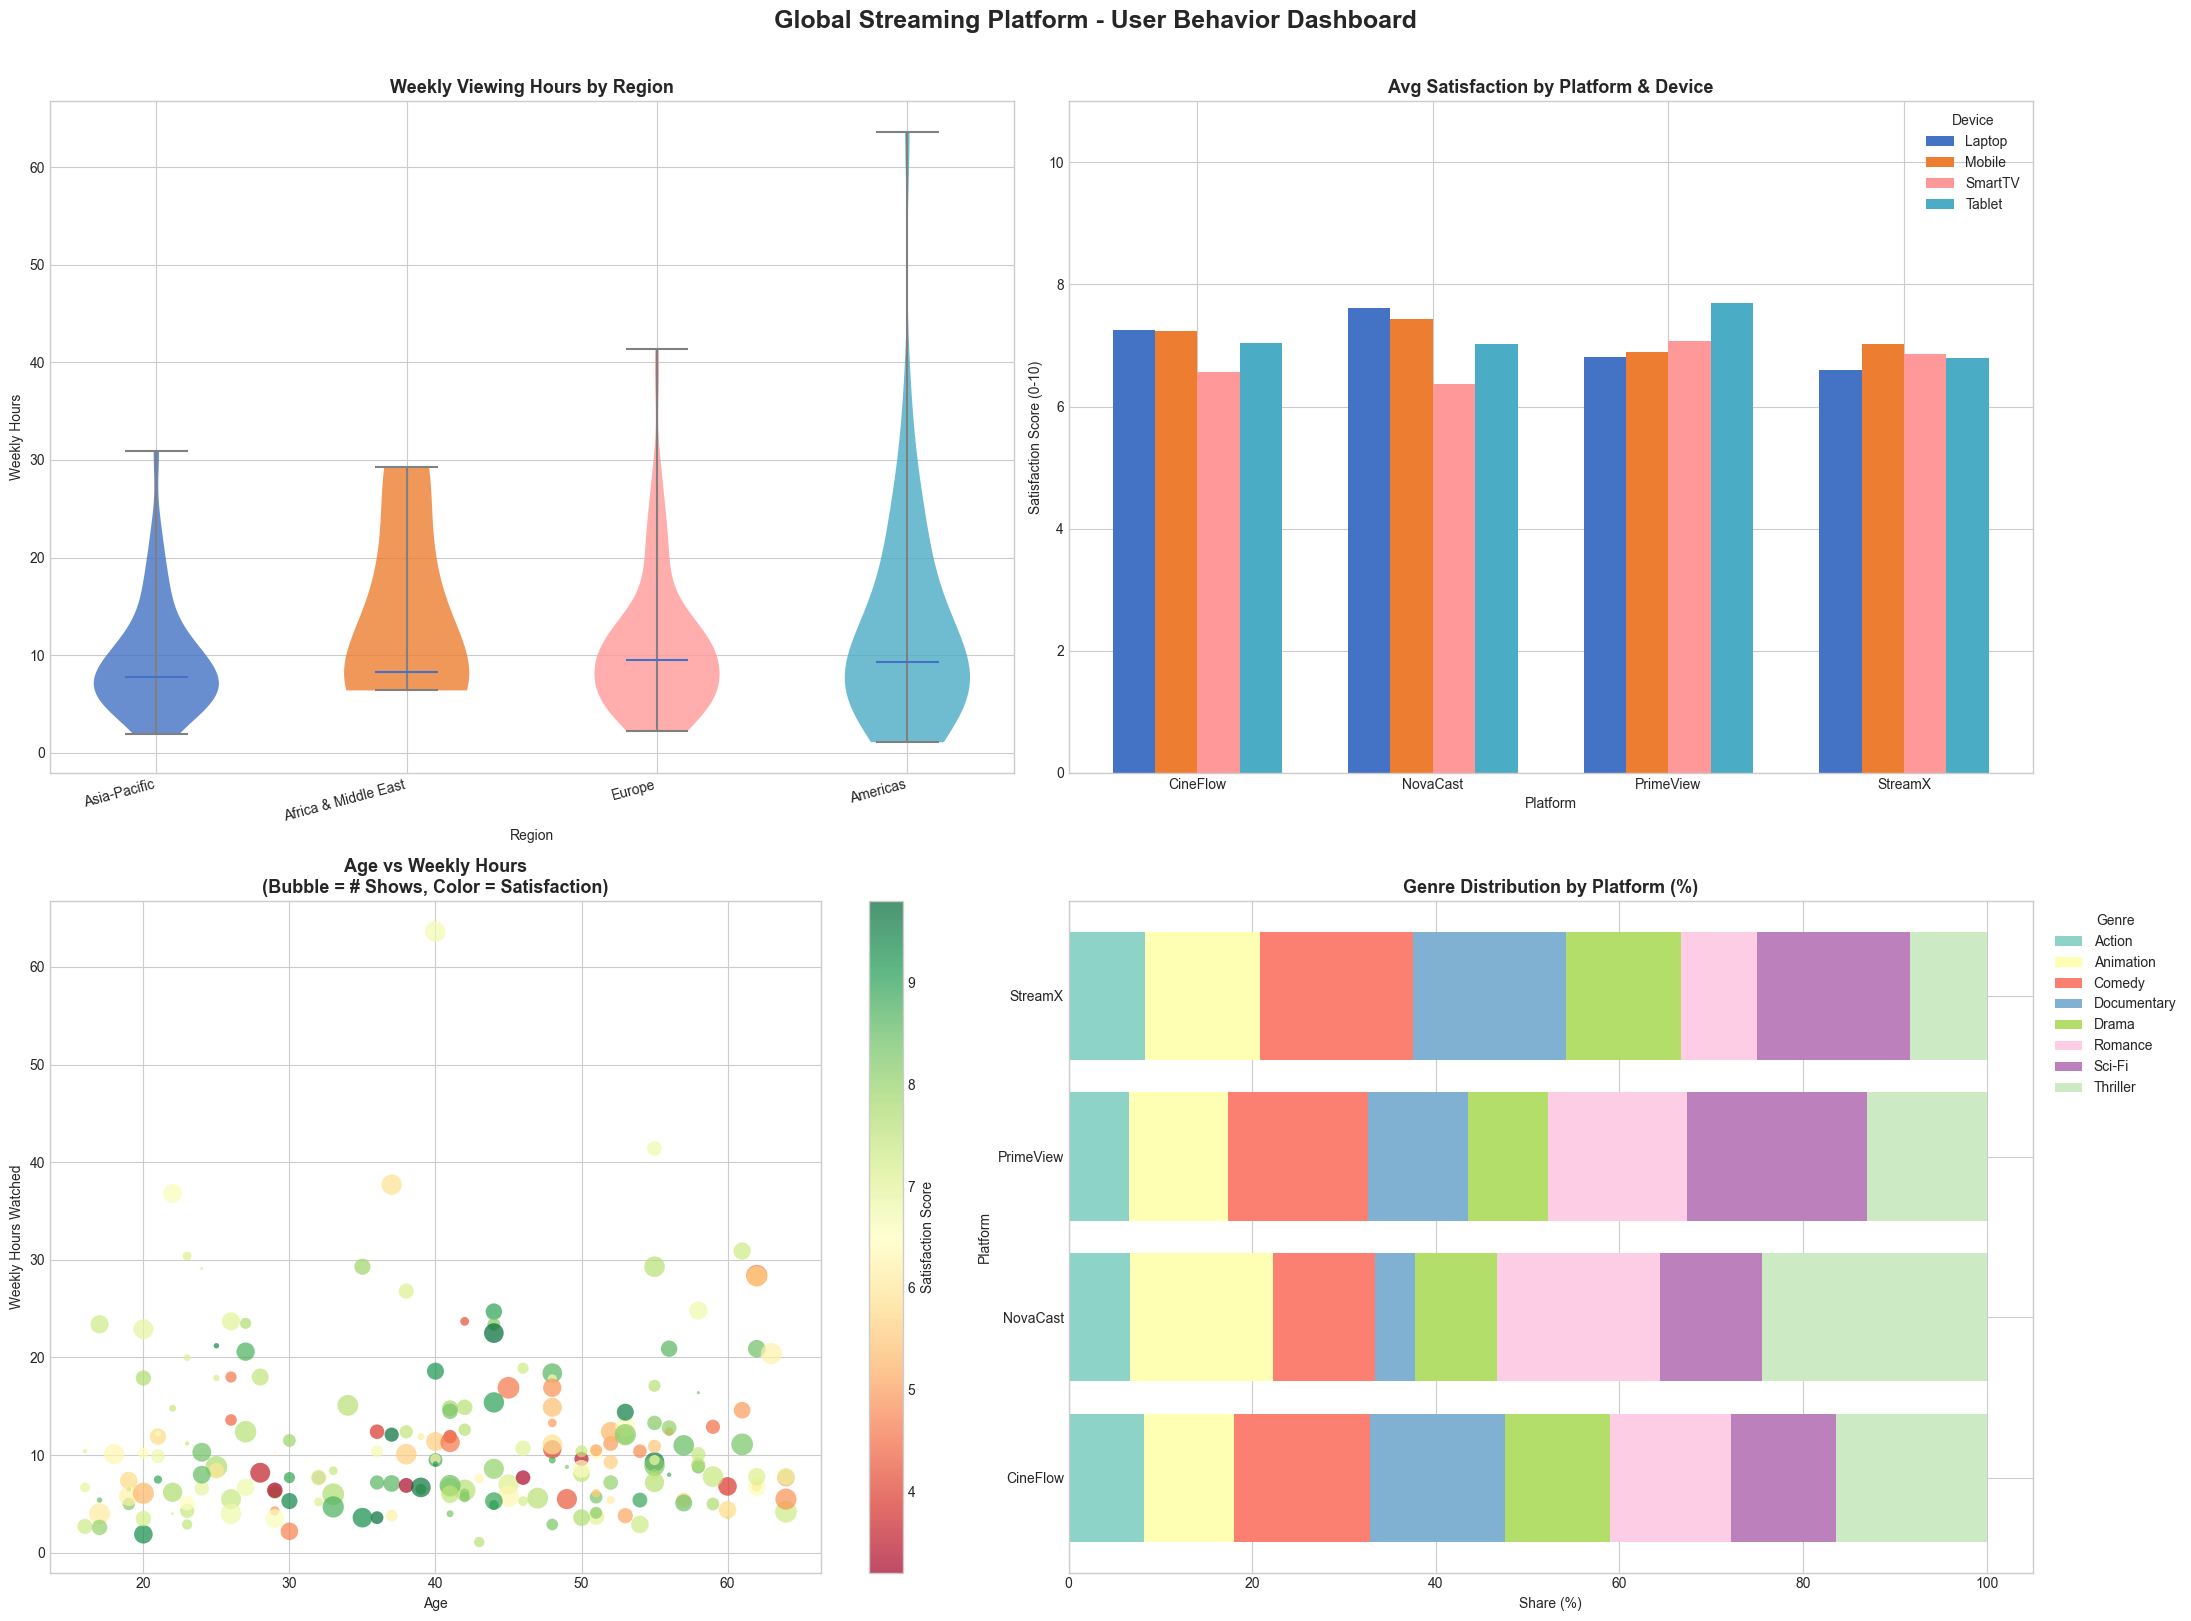

In [10]:
def problem1(filename):
    # Reads streaming_users.csv and builds a 4-panel dashboard figure.
    # Panels: violin plot, grouped bar chart, bubble chart, stacked horizontal bar.
    df = pd.read_csv(filename)

    # Map each country to a broader region
    region_map = {
        'USA': 'Americas', 'Canada': 'Americas', 'Brazil': 'Americas',
        'Argentina': 'Americas', 'Mexico': 'Americas',
        'Germany': 'Europe', 'France': 'Europe', 'UK': 'Europe',
        'Italy': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe',
        'Norway': 'Europe', 'Poland': 'Europe', 'Sweden': 'Europe', 'Turkey': 'Europe',
        'Japan': 'Asia-Pacific', 'South Korea': 'Asia-Pacific',
        'India': 'Asia-Pacific', 'Australia': 'Asia-Pacific',
        'Egypt': 'Africa & Middle East',
    }
    df['Region'] = df['Country'].map(region_map)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(22, 16))
    fig.suptitle('Global Streaming Platform - User Behavior Dashboard', fontsize=18, fontweight='bold', y=1.01)

    # Panel 1: Violin plot - weekly viewing hours distribution per region
    ax1 = axes[0, 0]

    regions_ordered = ['Asia-Pacific', 'Africa & Middle East', 'Europe', 'Americas']
    region_colors   = ['#4472C4', '#ED7D31', '#FF9999', '#4BACC6']

    violin_data = [df[df['Region'] == r]['Weekly_Hours'].dropna().values for r in regions_ordered]

    vp = ax1.violinplot(violin_data, positions=range(len(regions_ordered)),
                        showmedians=True, showextrema=True)

    # Color each violin body distinctly
    for body, color in zip(vp['bodies'], region_colors):
        body.set_facecolor(color)
        body.set_alpha(0.8)
    vp['cmedians'].set_color('#4472C4')
    vp['cmins'].set_color('grey')
    vp['cmaxes'].set_color('grey')
    vp['cbars'].set_color('grey')

    ax1.set_xticks(range(len(regions_ordered)))
    ax1.set_xticklabels(regions_ordered, rotation=15, ha='right')
    ax1.set_title('Weekly Viewing Hours by Region', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Region')
    ax1.set_ylabel('Weekly Hours')

    # Panel 2: Grouped bar chart - avg satisfaction score per platform and device
    ax2 = axes[0, 1]

    platforms = sorted(df['Platform'].unique())
    devices   = sorted(df['Device'].unique())
    device_colors = {'Laptop': '#4472C4', 'Mobile': '#ED7D31', 'SmartTV': '#FF9999', 'Tablet': '#4BACC6'}

    # Compute mean satisfaction for each (platform, device) pair
    grp = df.groupby(['Platform', 'Device'])['Satisfaction_Score'].mean().unstack(fill_value=0)

    n_devices = len(devices)
    bar_width  = 0.18
    x_pos      = np.arange(len(platforms))

    for i, device in enumerate(devices):
        offset = (i - n_devices / 2 + 0.5) * bar_width
        vals   = [grp.loc[p, device] if device in grp.columns else 0 for p in platforms]
        ax2.bar(x_pos + offset, vals, width=bar_width,
                label=device, color=device_colors[device])

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(platforms)
    ax2.set_ylim(0, 11)
    ax2.set_title('Avg Satisfaction by Platform & Device', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Platform')
    ax2.set_ylabel('Satisfaction Score (0-10)')
    ax2.legend(title='Device')

    # Panel 3: Bubble chart - age vs weekly hours, bubble size = shows watched, color = satisfaction
    ax3 = axes[1, 0]

    sc = ax3.scatter(
        df['Age'],
        df['Weekly_Hours'],
        s=df['Num_Shows_Watched'] * 5,   # scale bubble size as specified
        c=df['Satisfaction_Score'],
        cmap='RdYlGn',
        alpha=0.7,
        edgecolors='none'
    )
    cbar = fig.colorbar(sc, ax=ax3)
    cbar.set_label('Satisfaction Score')
    ax3.set_title('Age vs Weekly Hours\n(Bubble = # Shows, Color = Satisfaction)',
                  fontsize=13, fontweight='bold')
    ax3.set_xlabel('Age')
    ax3.set_ylabel('Weekly Hours Watched')

    # Panel 4: Stacked horizontal bar - genre share per platform (%)
    ax4 = axes[1, 1]

    genres = sorted(df['Genre'].unique())
    # Use Set3 colormap for distinct genre colors
    genre_colors = {g: plt.cm.Set3(i / len(genres)) for i, g in enumerate(genres)}

    genre_counts = df.groupby(['Platform', 'Genre']).size().unstack(fill_value=0)
    genre_pct    = genre_counts.div(genre_counts.sum(axis=1), axis=0) * 100

    platforms_bar = ['CineFlow', 'NovaCast', 'PrimeView', 'StreamX']
    lefts = np.zeros(len(platforms_bar))

    for genre in genres:
        vals = [genre_pct.loc[p, genre] if genre in genre_pct.columns else 0 for p in platforms_bar]
        ax4.barh(platforms_bar, vals, left=lefts, color=genre_colors[genre], label=genre)
        lefts += np.array(vals)

    ax4.set_xlabel('Share (%)')
    ax4.set_ylabel('Platform')
    ax4.set_title('Genre Distribution by Platform (%)', fontsize=13, fontweight='bold')
    ax4.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


problem1('streaming_users.csv')

## Problem 2: City Weather and AQI Dashboard

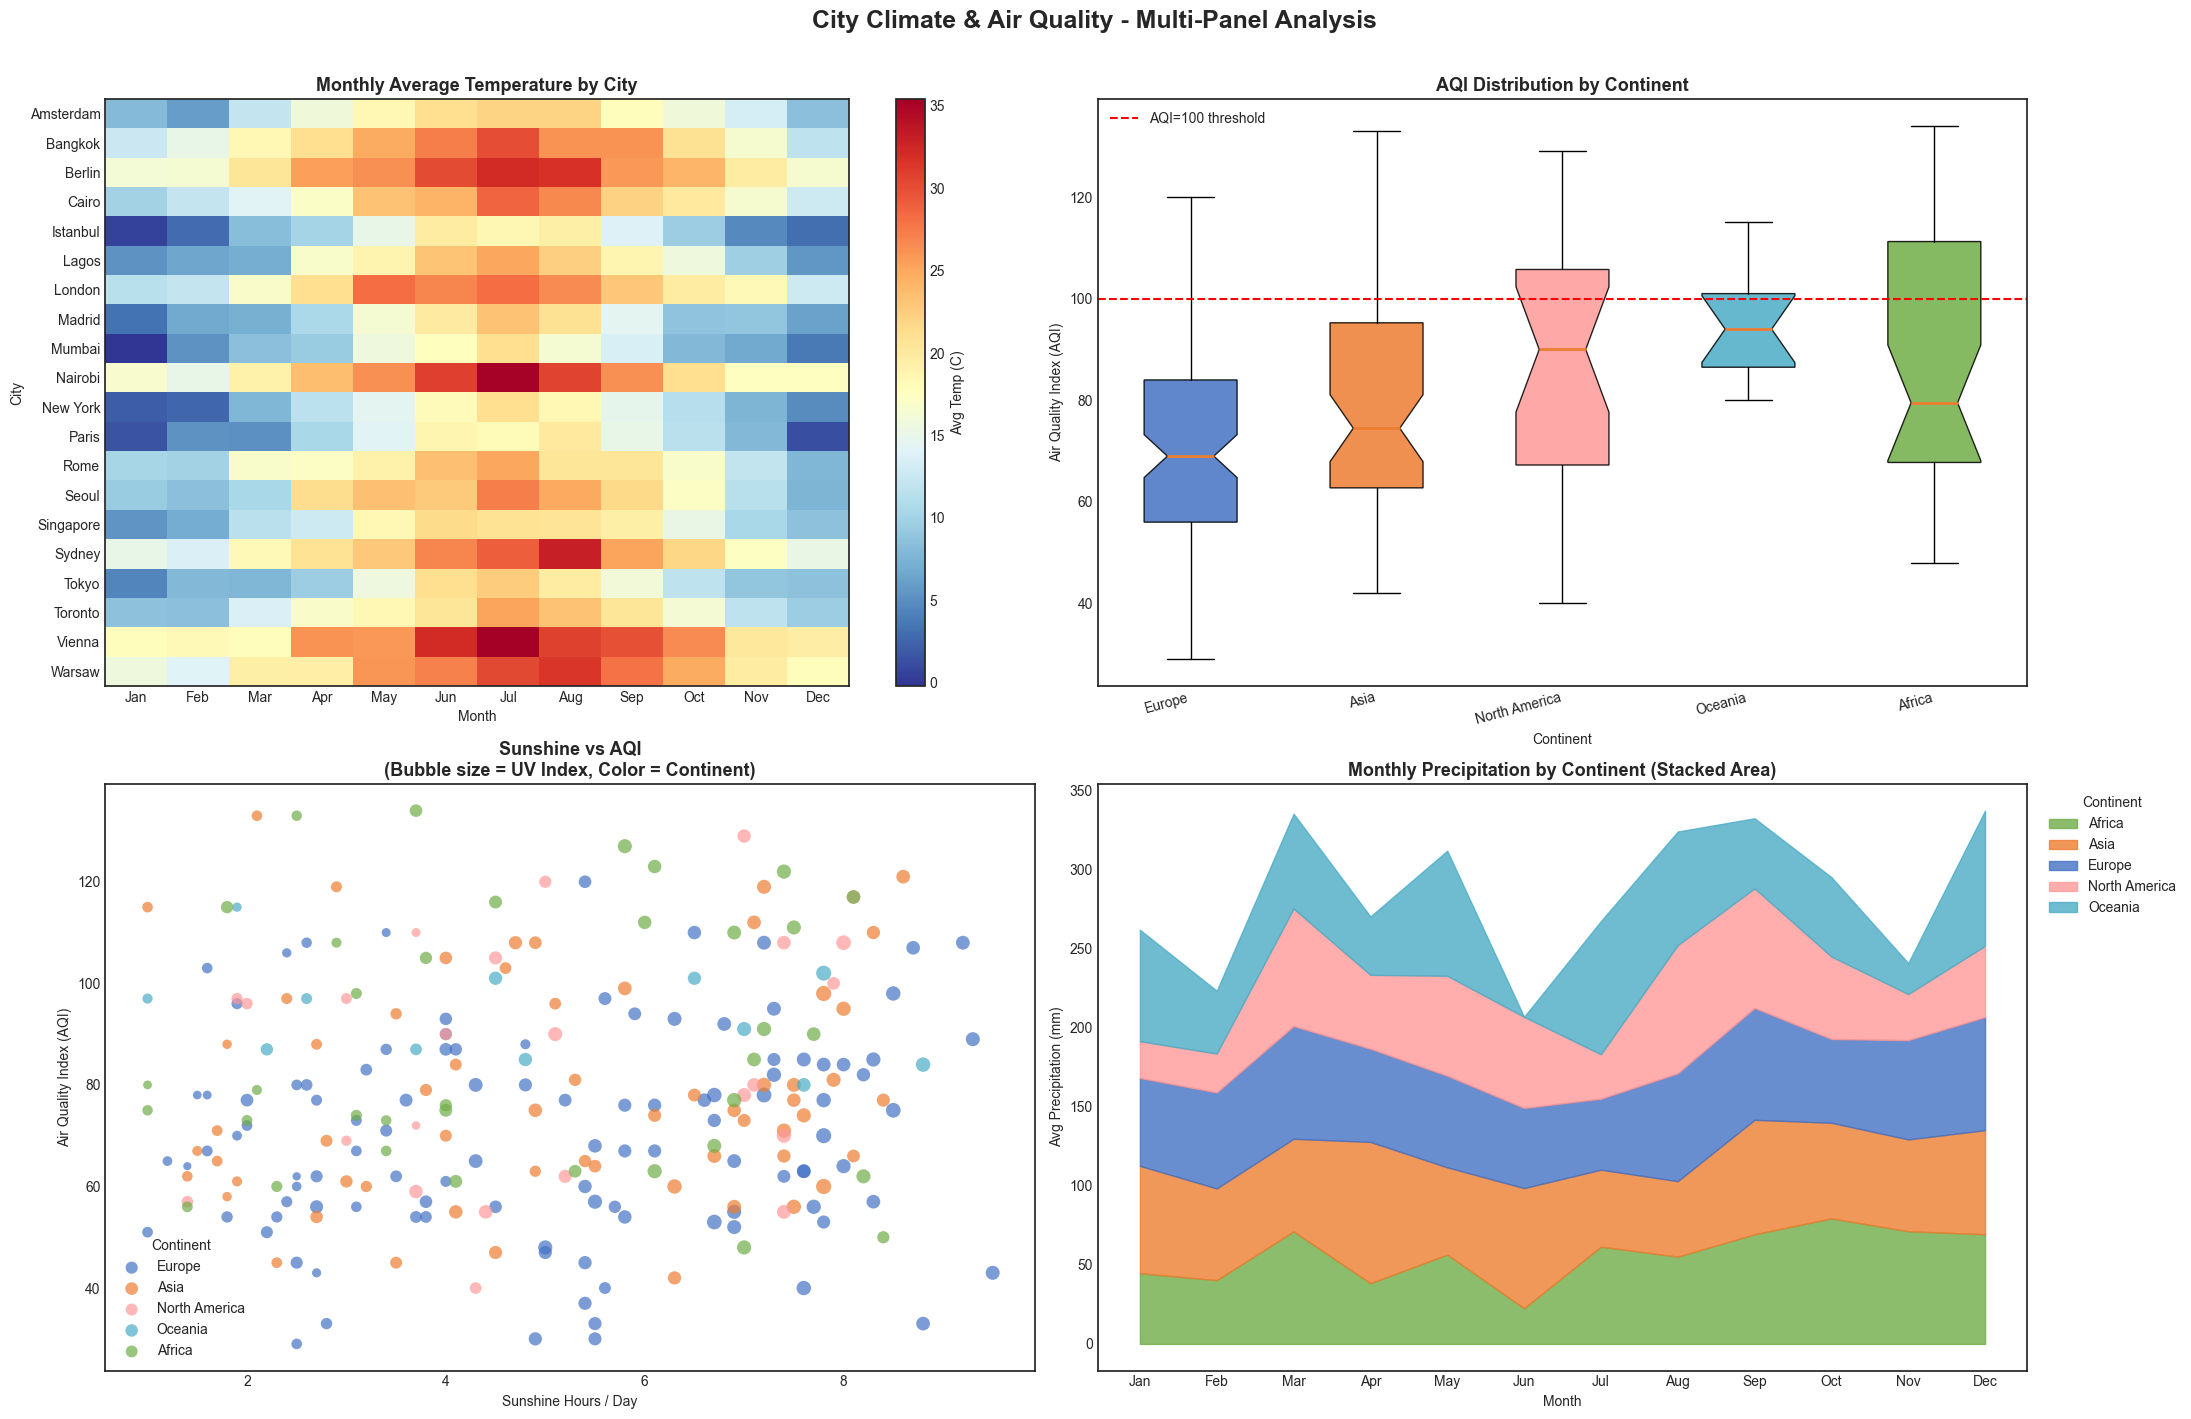

In [11]:
def problem2(filename):
    # Reads city_weather_aqi.csv and builds a 4-panel climate and air quality dashboard.
    # Panels: heatmap, notched boxplot, bubble scatter, stacked area chart.
    df = pd.read_csv(filename)

    # Enforce correct month ordering
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

    continents_box  = ['Europe', 'Asia', 'North America', 'Oceania', 'Africa']
    continents_area = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania']

    # Shared color palette reused across all panels
    continent_colors = {
        'Europe':        '#4472C4',
        'Asia':          '#ED7D31',
        'North America': '#FF9999',
        'Oceania':       '#4BACC6',
        'Africa':        '#70AD47',
    }

    plt.style.use('seaborn-v0_8-white')
    fig, axes = plt.subplots(2, 2, figsize=(22, 14))
    fig.suptitle('City Climate & Air Quality - Multi-Panel Analysis', fontsize=18, fontweight='bold', y=1.01)

    # Panel A: Heatmap - monthly average temperature per city (rows=city, cols=month)
    ax_a = axes[0, 0]

    heat_df = df.pivot_table(index='City', columns='Month', values='Avg_Temp_C', aggfunc='mean')
    heat_df = heat_df.reindex(columns=month_order)
    cities_sorted = sorted(heat_df.index.tolist())
    heat_df = heat_df.reindex(cities_sorted)

    im = ax_a.imshow(heat_df.values, cmap='RdYlBu_r', aspect='auto')
    cbar_a = fig.colorbar(im, ax=ax_a)
    cbar_a.set_label('Avg Temp (C)')

    ax_a.set_xticks(np.arange(len(month_order)))
    ax_a.set_xticklabels(month_order)
    ax_a.set_yticks(np.arange(len(cities_sorted)))
    ax_a.set_yticklabels(cities_sorted)
    ax_a.set_title('Monthly Average Temperature by City', fontsize=13, fontweight='bold')
    ax_a.set_xlabel('Month')
    ax_a.set_ylabel('City')

    # Panel B: Notched boxplot - AQI distribution per continent
    ax_b = axes[0, 1]

    box_data = [df[df['Continent'] == c]['AQI'].dropna().values for c in continents_box]
    bp = ax_b.boxplot(box_data, notch=True, patch_artist=True,
                      medianprops=dict(color='#ED7D31', linewidth=2))

    # Apply continent colors to boxes
    for patch, cont in zip(bp['boxes'], continents_box):
        patch.set_facecolor(continent_colors[cont])
        patch.set_alpha(0.85)

    # Reference line at AQI=100 (unhealthy threshold)
    ax_b.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='AQI=100 threshold')

    ax_b.set_xticks(range(1, len(continents_box) + 1))
    ax_b.set_xticklabels(continents_box, rotation=15, ha='right')
    ax_b.set_title('AQI Distribution by Continent', fontsize=13, fontweight='bold')
    ax_b.set_xlabel('Continent')
    ax_b.set_ylabel('Air Quality Index (AQI)')
    ax_b.legend(loc='upper left')

    # Panel C: Bubble scatter - sunshine hours vs AQI, bubble size = UV index
    ax_c = axes[1, 0]

    for cont in continents_box:
        sub = df[df['Continent'] == cont]
        ax_c.scatter(
            sub['Sunshine_Hours'],
            sub['AQI'],
            s=sub['UV_Index'] * 15,   # scale by 15 as specified
            color=continent_colors[cont],
            alpha=0.7,
            edgecolors='none',
            label=cont
        )

    ax_c.set_title('Sunshine vs AQI\n(Bubble size = UV Index, Color = Continent)',
                   fontsize=13, fontweight='bold')
    ax_c.set_xlabel('Sunshine Hours / Day')
    ax_c.set_ylabel('Air Quality Index (AQI)')
    ax_c.legend(title='Continent')

    # Panel D: Stacked area chart - mean monthly precipitation per continent
    ax_d = axes[1, 1]

    precip = (
        df.groupby(['Month', 'Continent'])['Precipitation_mm']
        .mean()
        .unstack(fill_value=0)
        .reindex(month_order)
    )

    x_idx    = np.arange(len(month_order))
    baseline = np.zeros(len(month_order))

    # Stack each continent on top of the previous
    for cont in continents_area:
        vals = precip[cont].values if cont in precip.columns else np.zeros(len(month_order))
        ax_d.fill_between(x_idx, baseline, baseline + vals,
                          color=continent_colors[cont], alpha=0.8, label=cont)
        baseline += vals

    ax_d.set_xticks(x_idx)
    ax_d.set_xticklabels(month_order)
    ax_d.set_title('Monthly Precipitation by Continent (Stacked Area)', fontsize=13, fontweight='bold')
    ax_d.set_xlabel('Month')
    ax_d.set_ylabel('Avg Precipitation (mm)')
    ax_d.legend(title='Continent', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


problem2('city_weather_aqi.csv')

In [12]:
# Data for Problem 3 - embedded directly from Steam Web API responses
import json

STEAM_DATA_RAW = [{"appid": 813780, "name": "Age of Empires II: Definitive Edition", "playtime_forever": 21507, "genres": ["Strategy"], "achievements": [{"name": "BERBERS_VICTORY", "unlocktime": 1719824010}, {"name": "BRITONS_VICTORY", "unlocktime": 1721588116}, {"name": "BULGARIANS_VICTORY", "unlocktime": 1725455551}, {"name": "BYZANTINES_VICTORY", "unlocktime": 1719821838}, {"name": "CELTS_VICTORY", "unlocktime": 1721584795}, {"name": "FRANKS_VICTORY", "unlocktime": 1718480524}, {"name": "GOTHS_VICTORY", "unlocktime": 1718898607}, {"name": "HUNS_VICTORY", "unlocktime": 1719357087}, {"name": "INCAS_VICTORY", "unlocktime": 1756834822}, {"name": "INDIANS_VICTORY", "unlocktime": 1719445839}, {"name": "ITALIANS_VICTORY", "unlocktime": 1719823194}, {"name": "JAPANESE_VICTORY", "unlocktime": 1718905586}, {"name": "KHMER_VICTORY", "unlocktime": 1721160061}, {"name": "KOREANS_VICTORY", "unlocktime": 1720015811}, {"name": "MAGYARS_VICTORY", "unlocktime": 1718484293}, {"name": "MONGOLS_VICTORY", "unlocktime": 1720636135}, {"name": "PERSIANS_VICTORY", "unlocktime": 1721749193}, {"name": "PORTUGUESE_VICTORY", "unlocktime": 1719416233}, {"name": "SARACENS_VICTORY", "unlocktime": 1718489341}, {"name": "SLAVS_VICTORY", "unlocktime": 1756482064}, {"name": "SPANISH_VICTORY", "unlocktime": 1719086578}, {"name": "TEUTONS_VICTORY", "unlocktime": 1718824789}, {"name": "TURKS_VICTORY", "unlocktime": 1719846347}, {"name": "VIKINGS_VICTORY", "unlocktime": 1769975797}, {"name": "ACHIEVEMENT_BULLS_EYE", "unlocktime": 1718480194}, {"name": "ACHIEVEMENT_ITS_A_TREB", "unlocktime": 1718480489}, {"name": "ACHIEVEMENT_KNOCKING_ON_YOUR_DOOR", "unlocktime": 1725717914}, {"name": "ACHIEVEMENT_CASTLE_CRUSHER", "unlocktime": 1719837884}, {"name": "LITHUANIANS_VICTORY", "unlocktime": 1725712761}, {"name": "ACHIEVEMENT_90_KG", "unlocktime": 1726055571}, {"name": "ACHIEVEMENT_OUT_OF_THEIR_ELEMENT", "unlocktime": 1721751105}, {"name": "ACHIEVEMENT_CASTLE_OF_DOUBT", "unlocktime": 1756853966}, {"name": "ACHIEVEMENT_PLEASANT_PEASANT", "unlocktime": 1718969318}, {"name": "ACHIEVEMENT_RELIC_HUNTER", "unlocktime": 1725653922}, {"name": "ACHIEVEMENT_BIRD_SHOOTING", "unlocktime": 1718477976}, {"name": "ACHIEVEMENT_DARK_DINNER", "unlocktime": 1693692402}, {"name": "ACHIEVEMENT_SHEEP_HOARDER", "unlocktime": 1769626197}, {"name": "ACHIEVEMENT_HOMELESS", "unlocktime": 1725889579}, {"name": "BURGUNDIANS_VICTORY", "unlocktime": 1769205636}, {"name": "SICILIANS_VICTORY", "unlocktime": 1720009461}, {"name": "ACHIEVEMENT_DONJON_SERJEANT", "unlocktime": 1720007714}, {"name": "BOHEMIANS_VICTORY", "unlocktime": 1719967004}, {"name": "ACHIEVEMENT_OOF_NICE", "unlocktime": 1769907815}, {"name": "DRAVIDIANS_VICTORY", "unlocktime": 1720985661}, {"name": "GURJARAS_VICTORY", "unlocktime": 1720027405}, {"name": "ACHIEVEMENT_NOT_JUST_A_MILITIA", "unlocktime": 1693301497}, {"name": "ACHIEVEMENT_FAMILY_FEUDAL", "unlocktime": 1757373757}, {"name": "ACHIEVEMENT_CAN_I_BE_FRANK_WITH_YOU", "unlocktime": 1718480544}, {"name": "ACHIEVEMENT_CHALLENGE_ACCEPTED", "unlocktime": 1719821828}, {"name": "ACHIEVEMENT_GOING_FOR_THE_GOLD", "unlocktime": 1719823995}, {"name": "ACHIEVEMENT_WINGMAN", "unlocktime": 1718898692}, {"name": "ACHIEVEMENT_BABY_BOOMER", "unlocktime": 1693300073}, {"name": "ACHIEVEMENT_BULL_MARKET", "unlocktime": 1718479313}, {"name": "ACHIEVEMENT_PREPARE_FOR_BOAR", "unlocktime": 1693300239}, {"name": "ROMAN_VICTORY", "unlocktime": 1719829972}, {"name": "POMPEII_ROMAN_VICTORY", "unlocktime": 1719834034}, {"name": "ACHIEVEMENT_AGILE_AS_A_SPARROW", "unlocktime": 1719835781}, {"name": "ARMENIANS_VICTORY", "unlocktime": 1720020422}], "total_achievements": 357}, {"appid": 1245620, "name": "ELDEN RING", "playtime_forever": 6117, "genres": ["Action", "RPG"], "achievements": [{"name": "ACH01", "unlocktime": 1738846685}, {"name": "ACH04", "unlocktime": 1734528800}, {"name": "ACH05", "unlocktime": 1734862861}, {"name": "ACH06", "unlocktime": 1735410558}, {"name": "ACH07", "unlocktime": 1735507325}, {"name": "ACH08", "unlocktime": 1738849980}, {"name": "ACH09", "unlocktime": 1738014167}, {"name": "ACH10", "unlocktime": 1738014167}, {"name": "ACH11", "unlocktime": 1738014167}, {"name": "ACH13", "unlocktime": 1734859380}, {"name": "ACH18", "unlocktime": 1734816418}, {"name": "ACH20", "unlocktime": 1738014167}, {"name": "ACH21", "unlocktime": 1738014167}, {"name": "ACH22", "unlocktime": 1738887268}, {"name": "ACH23", "unlocktime": 1734878255}, {"name": "ACH24", "unlocktime": 1738014167}, {"name": "ACH25", "unlocktime": 1734523181}, {"name": "ACH26", "unlocktime": 1734533399}, {"name": "ACH27", "unlocktime": 1734881232}, {"name": "ACH29", "unlocktime": 1734896504}, {"name": "ACH31", "unlocktime": 1734876995}, {"name": "ACH32", "unlocktime": 1738846685}, {"name": "ACH33", "unlocktime": 1738883245}, {"name": "ACH34", "unlocktime": 1735646338}, {"name": "ACH35", "unlocktime": 1738846685}, {"name": "ACH36", "unlocktime": 1738014167}, {"name": "ACH37", "unlocktime": 1734782515}, {"name": "ACH38", "unlocktime": 1738014167}, {"name": "ACH39", "unlocktime": 1734435066}, {"name": "ACH40", "unlocktime": 1734816418}, {"name": "ACH41", "unlocktime": 1738014167}], "total_achievements": 42}, {"appid": 1846380, "name": "Need for Speed™ Unbound", "playtime_forever": 2960, "genres": ["Action", "Racing"], "achievements": [{"name": "Achievement_GOSCC_2", "unlocktime": 1742951732}, {"name": "Achievement_GOSCC_3", "unlocktime": 1742984459}, {"name": "Achievement_GOSCC_4", "unlocktime": 1743464962}, {"name": "Achievement_GOSCC_5", "unlocktime": 1761934932}, {"name": "Achievement_GOSCC_7", "unlocktime": 1742810443}, {"name": "Achievement_GOSCC_15", "unlocktime": 1743255975}, {"name": "Achievement_GOSCC_16", "unlocktime": 1743255975}, {"name": "Achievement_GOSCC_19", "unlocktime": 1742822706}, {"name": "Achievement_GOSCC_21", "unlocktime": 1743253214}, {"name": "Achievement_GOSCC_22", "unlocktime": 1742984459}, {"name": "Achievement_GOSCC_23", "unlocktime": 1742467481}, {"name": "Achievement_GOSCC_24", "unlocktime": 1742974860}, {"name": "Achievement_GOSCC_33", "unlocktime": 1742825322}, {"name": "Achievement_GOSCC_35", "unlocktime": 1742830987}, {"name": "Achievement_GOSCC_36", "unlocktime": 1742471777}, {"name": "Achievement_GOSCC_37", "unlocktime": 1742467948}, {"name": "Achievement_GOSCC_38", "unlocktime": 1742933989}, {"name": "Achievement_GOSCC_39", "unlocktime": 1742468003}, {"name": "Achievement_GOSCC_41", "unlocktime": 1742467588}], "total_achievements": 41}, {"appid": 2669320, "name": "EA SPORTS FC™ 25", "playtime_forever": 1601, "genres": ["Simulation", "Sports"], "achievements": [{"name": "Achievement_GOSCC_25", "unlocktime": 1762708038}, {"name": "Achievement_GOSCC_36", "unlocktime": 1761674214}, {"name": "Achievement_GOSCC_37", "unlocktime": 1761676376}], "total_achievements": 39}, {"appid": 1888930, "name": "The Last of Us™ Part I", "playtime_forever": 1489, "genres": ["Action", "Adventure"], "achievements": [{"name": "284b17b75ee9e837", "unlocktime": 1763136574}, {"name": "d8be398c779c55da", "unlocktime": 1763236200}, {"name": "60dbb44ccacb0121", "unlocktime": 1762544575}, {"name": "33d7ce435071bec5", "unlocktime": 1763125176}, {"name": "71d5d57326f5b8f1", "unlocktime": 1762279197}, {"name": "2143304396bed9b2", "unlocktime": 1762351634}, {"name": "d6637d641c0a684f", "unlocktime": 1762366721}, {"name": "5d6eea83aff89166", "unlocktime": 1762371365}, {"name": "c87c609f99e09e9e", "unlocktime": 1762539462}, {"name": "f6bbd883545b7634", "unlocktime": 1762630957}, {"name": "b1c7582cb4bdbe80", "unlocktime": 1763232333}, {"name": "2a0b62cab5f059d9", "unlocktime": 1763230321}, {"name": "80b0d9d2f5a006fa", "unlocktime": 1763233049}], "total_achievements": 29}, {"appid": 1222700, "name": "A Way Out", "playtime_forever": 1356, "genres": ["Action", "Adventure", "Indie"], "achievements": [{"name": "Achievement_GOSCC_1", "unlocktime": 1751495745}, {"name": "Achievement_GOSCC_6", "unlocktime": 1751569459}, {"name": "Achievement_GOSCC_10", "unlocktime": 1751556924}, {"name": "Achievement_GOSCC_14", "unlocktime": 1755804955}], "total_achievements": 14}, {"appid": 976310, "name": "Mortal Kombat 11", "playtime_forever": 949, "genres": ["Action"], "achievements": [{"name": "trophy-ID004", "unlocktime": 1755382976}, {"name": "trophy-ID005", "unlocktime": 1755888928}, {"name": "trophy-ID015", "unlocktime": 1750094521}, {"name": "trophy-ID027", "unlocktime": 1749761489}, {"name": "trophy-ID033", "unlocktime": 1749917354}, {"name": "trophy-ID037", "unlocktime": 1755888928}, {"name": "trophy-ID058", "unlocktime": 1750094512}], "total_achievements": 58}, {"appid": 1659420, "name": "UNCHARTED™: Legacy of Thieves Collection", "playtime_forever": 918, "genres": ["Adventure"], "achievements": [{"name": "TROPHY_NAME_TREASURE_1", "unlocktime": 1763817639}, {"name": "TROPHY_NAME_JOURNAL_ENTRY_1", "unlocktime": 1763974515}, {"name": "TROPHY_NAME_JOURNAL_NOTE_1", "unlocktime": 1763973881}, {"name": "TROPHY_NAME_HEADSHOT_LOW", "unlocktime": 1763835600}, {"name": "TROPHY_NAME_HEADSHOT_HIGH", "unlocktime": 1764007912}, {"name": "TROPHY_NAME_STEALTH_KILL_LOW", "unlocktime": 1763833168}, {"name": "TROPHY_NAME_STEALTH_KILL_HIGH", "unlocktime": 1764092188}, {"name": "TROPHY_NAME_LEMUR_CITY", "unlocktime": 1764271352}], "total_achievements": 101}, {"appid": 627270, "name": "Injustice™ 2", "playtime_forever": 898, "genres": ["Action"], "achievements": [{"name": "TROPHY_ID_COMPLETE_50_PERCENT_STORYMODE", "unlocktime": 1742418464}, {"name": "TROPHY_ID_COMPLETE_100_PERCENT_STORYMODE", "unlocktime": 1742742011}, {"name": "TROPHY_ID_GO_10_SECONDS_WITHOUT_BEING_HIT", "unlocktime": 1742350348}], "total_achievements": 74}, {"appid": 730, "name": "Counter-Strike 2", "playtime_forever": 818, "genres": ["Action", "Free To Play"], "achievements": [], "total_achievements": 1}, {"appid": 601150, "name": "Devil May Cry 5", "playtime_forever": 690, "genres": ["Action"], "achievements": [{"name": "Achievements_06", "unlocktime": 1755385495}, {"name": "Achievements_09", "unlocktime": 1755398346}, {"name": "Achievements_10", "unlocktime": 1755442178}, {"name": "Achievements_11", "unlocktime": 1755443404}, {"name": "Achievements_12", "unlocktime": 1755445673}, {"name": "Achievements_14", "unlocktime": 1755461147}, {"name": "Achievements_15", "unlocktime": 1755516174}, {"name": "Achievements_16", "unlocktime": 1755520780}, {"name": "Achievements_17", "unlocktime": 1755531007}, {"name": "Achievements_18", "unlocktime": 1755535026}, {"name": "Achievements_20", "unlocktime": 1756818831}, {"name": "Achievements_21", "unlocktime": 1756822751}, {"name": "Achievements_26", "unlocktime": 1755392446}, {"name": "Achievements_27", "unlocktime": 1755441729}, {"name": "Achievements_28", "unlocktime": 1755441735}, {"name": "Achievements_34", "unlocktime": 1755519343}, {"name": "Achievements_46", "unlocktime": 1755455626}, {"name": "Achievements_47", "unlocktime": 1755444720}], "total_achievements": 55}, {"appid": 550, "name": "Left 4 Dead 2", "playtime_forever": 629, "genres": ["Action"], "achievements": [{"name": "ACH_KILL_SPITTER_FAST", "unlocktime": 1705962729}, {"name": "ACH_SAVE_PLAYER_FROM_JOCKEY_FAST", "unlocktime": 1706129307}, {"name": "ACH_DEPLOY_AMMO_UPGRADE", "unlocktime": 1706125862}, {"name": "ACH_BILE_A_TANK", "unlocktime": 1718142739}, {"name": "ACH_VS_JOCKEY_TWO_PLAYERS", "unlocktime": 1706124261}, {"name": "ACH_VS_SPIT_ON_ENEMY_TEAM", "unlocktime": 1705964884}, {"name": "ACH_VS_SPIT_ON_SMOKERED_PLAYER", "unlocktime": 1705967307}, {"name": "ACH_VS_CHARGER_GROUND_SMASH", "unlocktime": 1706116217}, {"name": "ACH_VS_SPIT_ON_CHARGED_PLAYER", "unlocktime": 1705963953}, {"name": "ACH_VS_SPIT_ON_POUNCED_PLAYER", "unlocktime": 1706130490}, {"name": "ACH_VS_BILE_PLAYER_NO_LINE_OF_SIGHT", "unlocktime": 1706117994}, {"name": "GLOBAL_GNOME_ALONE", "unlocktime": 1705960757}], "total_achievements": 101}, {"appid": 880940, "name": "Pummel Party", "playtime_forever": 541, "genres": ["Action", "Casual", "Indie"], "achievements": [{"name": "ACH_FIRST_GAME", "unlocktime": 1751201984}, {"name": "ACH_WIN_FIRST_MINIGAME", "unlocktime": 1751202419}, {"name": "ACH_FIRST_GOAL", "unlocktime": 1751204967}, {"name": "ACH_WIN_FIRST_GAME", "unlocktime": 1751235273}, {"name": "ACH_MADE_A_MISTAKE", "unlocktime": 1751248091}, {"name": "ACH_ELEMENTAL_ESCALATION", "unlocktime": 1751241482}, {"name": "ACH_THUNDEROUS_TRENCH", "unlocktime": 1751208079}, {"name": "ACH_SPEEDY_SABERS", "unlocktime": 1751205765}, {"name": "ACH_TUNNELING_TANKS", "unlocktime": 1751409810}, {"name": "ACH_ACIDIC_ATOLL", "unlocktime": 1751205529}, {"name": "ACH_MAGMA_MAGES", "unlocktime": 1751242206}, {"name": "ACH_WINTER_MAZE", "unlocktime": 1751208381}, {"name": "ACH_BOUNCING_BALLS", "unlocktime": 1751204967}], "total_achievements": 31}, {"appid": 1537830, "name": "Disney Speedstorm", "playtime_forever": 446, "genres": ["Action", "Adventure", "Casual", "Racing", "Simulation", "Sports", "Free To Play"], "achievements": [], "total_achievements": 24}, {"appid": 2290180, "name": "Riders Republic", "playtime_forever": 309, "genres": ["Massively Multiplayer", "Sports"], "achievements": [{"name": "RRepublic_Ach_9", "unlocktime": 1751982592}, {"name": "RRepublic_Ach_12", "unlocktime": 1751838141}, {"name": "RRepublic_Ach_19", "unlocktime": 1751836764}], "total_achievements": 34}, {"appid": 612880, "name": "Wolfenstein II: The New Colossus", "playtime_forever": 189, "genres": ["Action"], "achievements": [{"name": "ach_1", "unlocktime": 1742343939}, {"name": "ach_2", "unlocktime": 1749750246}], "total_achievements": 80}, {"appid": 674940, "name": "Stick Fight: The Game", "playtime_forever": 90, "genres": ["Action", "Casual", "Indie"], "achievements": [{"name": "Ace", "unlocktime": 1751236896}, {"name": "RoyalAce", "unlocktime": 1751237395}, {"name": "Explorer", "unlocktime": 1751239659}, {"name": "Conqueror", "unlocktime": 1751239659}, {"name": "Blackhole", "unlocktime": 1751237417}, {"name": "DoubleKill", "unlocktime": 1751236896}, {"name": "KillingSpree", "unlocktime": 1751237102}, {"name": "Rampage", "unlocktime": 1751237571}, {"name": "Dominating", "unlocktime": 1751239012}, {"name": "Unstoppable", "unlocktime": 1751240018}, {"name": "Genocide", "unlocktime": 1751240037}, {"name": "Godlike", "unlocktime": 1751240046}, {"name": "WickedStick", "unlocktime": 1751240050}, {"name": "Snake", "unlocktime": 1751236768}, {"name": "StickIrvin", "unlocktime": 1751237102}, {"name": "Ricochet", "unlocktime": 1751239991}, {"name": "YourKungFuIsStrong", "unlocktime": 1751236895}, {"name": "Walkover", "unlocktime": 1751236176}, {"name": "APoultryMeal", "unlocktime": 1751238278}, {"name": "Headshot", "unlocktime": 1751237779}], "total_achievements": 28}, {"appid": 1065310, "name": "Evil West", "playtime_forever": 69, "genres": ["Action", "Adventure", "RPG"], "achievements": [{"name": "ACH_FINISHERS", "unlocktime": 1741547728}], "total_achievements": 30}, {"appid": 782330, "name": "DOOM Eternal", "playtime_forever": 66, "genres": ["Action"], "achievements": [{"name": "NEW_ACHIEVEMENT_1_25", "unlocktime": 1757204470}], "total_achievements": 50}, {"appid": 386940, "name": "Ultimate Chicken Horse", "playtime_forever": 61, "genres": ["Action", "Casual", "Indie"], "achievements": [{"name": "Young_Explorer", "unlocktime": 1751324068}, {"name": "Craftsperson", "unlocktime": 1751322841}, {"name": "Engineer", "unlocktime": 1751322841}], "total_achievements": 31}, {"appid": 1938090, "name": "Call of Duty®", "playtime_forever": 37, "genres": ["Action"], "achievements": [], "total_achievements": 157}, {"appid": 683320, "name": "GRIS", "playtime_forever": 30, "genres": ["Adventure", "Indie"], "achievements": [{"name": "Z1_DISCOVER_RED", "unlocktime": 1762102881}], "total_achievements": 17}, {"appid": 1815780, "name": "Asphalt Legends ", "playtime_forever": 29, "genres": ["Action", "Adventure", "Racing", "Sports", "Free To Play"], "achievements": [{"name": "ACHIEVEMENT_WIN_THE_RACE", "unlocktime": 1749672824}], "total_achievements": 42}, {"appid": 500, "name": "Left 4 Dead", "playtime_forever": 1, "genres": ["Action"], "achievements": [], "total_achievements": 73}, {"appid": 48000, "name": "LIMBO", "playtime_forever": 0, "genres": ["Action", "Adventure", "Indie"], "achievements": [], "total_achievements": 0}, {"appid": 49520, "name": "Borderlands 2", "playtime_forever": 0, "genres": ["Action", "RPG"], "achievements": [], "total_achievements": 0}, {"appid": 236850, "name": "Europa Universalis IV", "playtime_forever": 0, "genres": ["Simulation", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 304430, "name": "INSIDE", "playtime_forever": 0, "genres": ["Action", "Adventure", "Indie"], "achievements": [], "total_achievements": 0}, {"appid": 312840, "name": "Fahrenheit: Indigo Prophecy Remastered", "playtime_forever": 0, "genres": ["Adventure", "RPG"], "achievements": [], "total_achievements": 0}, {"appid": 327030, "name": "Worms W.M.D", "playtime_forever": 0, "genres": ["Action", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 397540, "name": "Borderlands 3", "playtime_forever": 0, "genres": ["Action", "RPG"], "achievements": [], "total_achievements": 0}, {"appid": 502500, "name": "ACE COMBAT™7: SKIES UNKNOWN", "playtime_forever": 0, "genres": ["Action", "Simulation"], "achievements": [], "total_achievements": 0}, {"appid": 508440, "name": "Totally Accurate Battle Simulator", "playtime_forever": 0, "genres": ["Indie", "Simulation", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 521890, "name": "Hello Neighbor", "playtime_forever": 0, "genres": ["Adventure", "Indie", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 552500, "name": "Warhammer: Vermintide 2", "playtime_forever": 0, "genres": ["Action", "Indie", "RPG"], "achievements": [], "total_achievements": 0}, {"appid": 859570, "name": "Secret Neighbor", "playtime_forever": 0, "genres": ["Action", "Adventure", "Indie"], "achievements": [], "total_achievements": 0}, {"appid": 960420, "name": "Hello Neighbor: Hide and Seek", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 960910, "name": "Heavy Rain", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 960990, "name": "Beyond: Two Souls", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 1172380, "name": "STAR WARS Jedi: Fallen Order™ ", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 1222140, "name": "Detroit: Become Human", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 1225570, "name": "Unravel Two", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 1238810, "name": "Battlefield™ V", "playtime_forever": 0, "genres": ["Action"], "achievements": [], "total_achievements": 0}, {"appid": 1238840, "name": "Battlefield™ 1", "playtime_forever": 0, "genres": ["Action", "Massively Multiplayer"], "achievements": [], "total_achievements": 0}, {"appid": 1238860, "name": "Battlefield 4™ ", "playtime_forever": 0, "genres": ["Action"], "achievements": [], "total_achievements": 0}, {"appid": 1321680, "name": "Hello Neighbor 2", "playtime_forever": 0, "genres": ["Adventure", "Indie", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 1426210, "name": "It Takes Two", "playtime_forever": 0, "genres": ["Action", "Adventure"], "achievements": [], "total_achievements": 0}, {"appid": 1517290, "name": "Battlefield™ 2042", "playtime_forever": 0, "genres": ["Action", "Adventure", "Casual"], "achievements": [], "total_achievements": 0}, {"appid": 1608450, "name": "Hellslave", "playtime_forever": 0, "genres": ["Adventure", "Indie", "RPG", "Strategy"], "achievements": [], "total_achievements": 0}, {"appid": 2592160, "name": "Dispatch", "playtime_forever": 0, "genres": ["Action", "Adventure", "Casual", "Indie", "Strategy"], "achievements": [], "total_achievements": 0}]

AOE2_STATS_RAW = [{"name": "STAT_TOTAL_GAMES", "value": 387}, {"name": "STAT_NUM_WINS", "value": 192}, {"name": "STAT_NUM_MVP_AWARDS", "value": 171}, {"name": "STAT_VICTORY_BRITONS", "value": 2}, {"name": "STAT_VICTORY_FRANKS", "value": 7}, {"name": "STAT_VICTORY_GOTHS", "value": 18}, {"name": "STAT_VICTORY_TEUTONS", "value": 15}, {"name": "STAT_VICTORY_JAPANESE", "value": 20}, {"name": "STAT_VICTORY_BYZANTINES", "value": 33}, {"name": "STAT_VICTORY_PERSIANS", "value": 9}, {"name": "STAT_VICTORY_SARACENS", "value": 2}, {"name": "STAT_VICTORY_TURKS", "value": 3}, {"name": "STAT_VICTORY_VIKINGS", "value": 2}, {"name": "STAT_VICTORY_MONGOLS", "value": 9}, {"name": "STAT_VICTORY_CELTS", "value": 4}, {"name": "STAT_VICTORY_SPANISH", "value": 8}, {"name": "STAT_VICTORY_HUNS", "value": 5}, {"name": "STAT_VICTORY_KOREANS", "value": 4}, {"name": "STAT_VICTORY_ITALIANS", "value": 3}, {"name": "STAT_VICTORY_INDIANS", "value": 17}, {"name": "STAT_VICTORY_INCAS", "value": 2}, {"name": "STAT_VICTORY_MAGYAR", "value": 6}, {"name": "STAT_VICTORY_SLAVS", "value": 5}, {"name": "STAT_VICTORY_PORTUGUESE", "value": 11}, {"name": "STAT_VICTORY_BERBERS", "value": 2}, {"name": "STAT_VICTORY_KHMER", "value": 2}, {"name": "STAT_VICTORY_BULGARIANS", "value": 36}, {"name": "STAT_VICTORY_RANDOM", "value": 1}, {"name": "STAT_HIGHEST_SCORE_TOTAL", "value": 41192}, {"name": "STAT_HIGHEST_SCORE_MILITARY", "value": 28485}, {"name": "STAT_HIGHEST_SCORE_ECONOMIC", "value": 32061}, {"name": "STAT_HIGHEST_SCORE_TECHNOLOGY", "value": 5219}, {"name": "STAT_HIGHEST_SCORE_SOCIETY", "value": 2730}, {"name": "STAT_CAREER_UNITS_KILLED", "value": 69896}, {"name": "STAT_CAREER_UNITS_LOST", "value": 62430}, {"name": "STAT_CAREER_UNITS_CONVERTED", "value": 108}, {"name": "STAT_CAREER_BUILDINGS_RAZED", "value": 6697}, {"name": "STAT_CAREER_BUILDINGS_LOST", "value": 5838}, {"name": "STAT_CAREER_NUM_CASTLES", "value": 893}, {"name": "STAT_GAMES_PLAYED_OFFLINE", "value": 104}, {"name": "STAT_GAMES_PLAYED_ONLINE", "value": 387}, {"name": "STAT_GAMES_PLAYED_RANDOM", "value": 455}, {"name": "STAT_DEFEATED_BRITONS", "value": 39}, {"name": "STAT_DEFEATED_FRANKS", "value": 38}, {"name": "STAT_DEFEATED_GOTHS", "value": 17}, {"name": "STAT_DEFEATED_TEUTONS", "value": 21}, {"name": "STAT_DEFEATED_JAPANESE", "value": 11}, {"name": "STAT_DEFEATED_CHINESE", "value": 18}, {"name": "STAT_DEFEATED_BYZANTINES", "value": 15}, {"name": "STAT_DEFEATED_PERSIANS", "value": 27}, {"name": "STAT_DEFEATED_SARACENS", "value": 7}, {"name": "STAT_DEFEATED_TURKS", "value": 25}, {"name": "STAT_DEFEATED_VIKINGS", "value": 7}, {"name": "STAT_DEFEATED_MONGOLS", "value": 21}, {"name": "STAT_DEFEATED_CELTS", "value": 8}, {"name": "STAT_DEFEATED_SPANISH", "value": 31}, {"name": "STAT_DEFEATED_AZTECS", "value": 6}, {"name": "STAT_DEFEATED_MAYANS", "value": 9}, {"name": "STAT_DEFEATED_HUNS", "value": 31}, {"name": "STAT_DEFEATED_KOREANS", "value": 6}, {"name": "STAT_DEFEATED_ITALIANS", "value": 10}, {"name": "STAT_DEFEATED_INDIANS", "value": 7}, {"name": "STAT_DEFEATED_INCAS", "value": 4}, {"name": "STAT_DEFEATED_MAGYAR", "value": 10}, {"name": "STAT_DEFEATED_SLAVS", "value": 9}, {"name": "STAT_DEFEATED_PORTUGUESE", "value": 13}, {"name": "STAT_DEFEATED_ETHIOPIANS", "value": 7}, {"name": "STAT_DEFEATED_MALIANS", "value": 5}, {"name": "STAT_DEFEATED_BERBERS", "value": 2}, {"name": "STAT_DEFEATED_KHMER", "value": 34}, {"name": "STAT_DEFEATED_MALAY", "value": 7}, {"name": "STAT_DEFEATED_BURMESE", "value": 2}, {"name": "STAT_DEFEATED_VIETNAMESE", "value": 9}, {"name": "STAT_DEFEATED_BULGARIANS", "value": 15}, {"name": "STAT_DEFEATED_TATARS", "value": 6}, {"name": "STAT_DEFEATED_CUMANS", "value": 8}, {"name": "STAT_SINGLEBATTLE_UNITS_KILLED", "value": 1764}, {"name": "STAT_SINGLEBATTLE_UNITS_LOST", "value": 1530}, {"name": "STAT_SINGLEBATTLE_UNITS_CONVERTED", "value": 4}, {"name": "STAT_SINGLEBATTLE_BUILDINGS_RAZED", "value": 237}, {"name": "STAT_SINGLEBATTLE_BUILDINGS_LOST", "value": 133}, {"name": "STAT_SINGLEBATTLE_NUM_CASTLES", "value": 893}, {"name": "STAT_OVERALL_GAME_STARTS", "value": 508}, {"name": "STAT_OVERALL_STDSTARTS", "value": 81}, {"name": "STAT_OVERALL_CAMPSTARTS", "value": 35}, {"name": "STAT_CAREER_KILLED_BY_DEMOS", "value": 8}, {"name": "STAT_CAREER_KILLED_BY_TREBS", "value": 183}, {"name": "STAT_CAREER_KILLED_BY_MANGOS", "value": 361}, {"name": "STAT_CAREER_DESTROYED_BY_RAMS", "value": 236}, {"name": "STAT_CAREER_CASTLES_DESTROYED", "value": 157}, {"name": "STAT_VICTORY_LITHUANIANS", "value": 2}, {"name": "STAT_DEFEATED_LITHUANIANS", "value": 13}, {"name": "STAT_TREBS_BUILT", "value": 402}, {"name": "STAT_CONDOTTIERO_TRAINED", "value": 51}, {"name": "STAT_FARMS_BUILT", "value": 1180}, {"name": "STAT_RELICS_COLLECTED", "value": 305}, {"name": "STAT_CHU_KO_NU_ARROWS_FIRED", "value": 44}, {"name": "STAT_POP_CAP_200_SP", "value": 51}, {"name": "STAT_POP_PEAK_200_SP", "value": 1696}, {"name": "STAT_PLAYED_Coastal", "value": 5}, {"name": "STAT_POP_CAP_200_MP", "value": 386}, {"name": "STAT_POP_PEAK_200_MP", "value": 52322}, {"name": "STAT_VICTORY_BURGUNDIANS", "value": 2}, {"name": "STAT_VICTORY_SICILIANS", "value": 2}, {"name": "STAT_VICTORY_BOHEMIANS", "value": 6}, {"name": "STAT_VICTORY_DRAVIDIANS", "value": 2}, {"name": "STAT_VICTORY_GURJARAS", "value": 2}, {"name": "STAT_VICTORY_ROMANS", "value": 6}, {"name": "STAT_DEFEATED_ROMANS", "value": 15}, {"name": "STAT_DEFEATED_POMPEII_EGYPTIAN", "value": 1}, {"name": "STAT_VICTORY_POMPEII_ROMAN", "value": 2}, {"name": "STAT_DEFEATED_POMPEII_ROMAN", "value": 4}, {"name": "STAT_VICTORY_POMPEII_YAMATO", "value": 2}, {"name": "STAT_POMPEII_WIN_STREAK", "value": 2}, {"name": "STAT_GAMES_PLAYED_OFFLINE_POMPEII", "value": 5}, {"name": "STAT_GAMES_PLAYED_ONLINE_POMPEII", "value": 1}, {"name": "STAT_VICTORY_ARMENIANS", "value": 3}]


## Problem 3: My Steam Library, How Did I Spend My Gaming Hours?

This visualization explores my personal Steam gaming library using data fetched from the Steam Web API. The dataset includes playtime, genres, and achievement progress for 50 games, plus in-game statistics for Age of Empires II: Definitive Edition, my most played game (358 hours). The story I want to tell is: **where did my gaming hours actually go?** - across games, genres, achievement completion, and civilization choices in AoE2. Data is embedded directly in this notebook as Python lists (STEAM_DATA_RAW, AOE2_STATS_RAW), originally fetched via the Steam Web API.

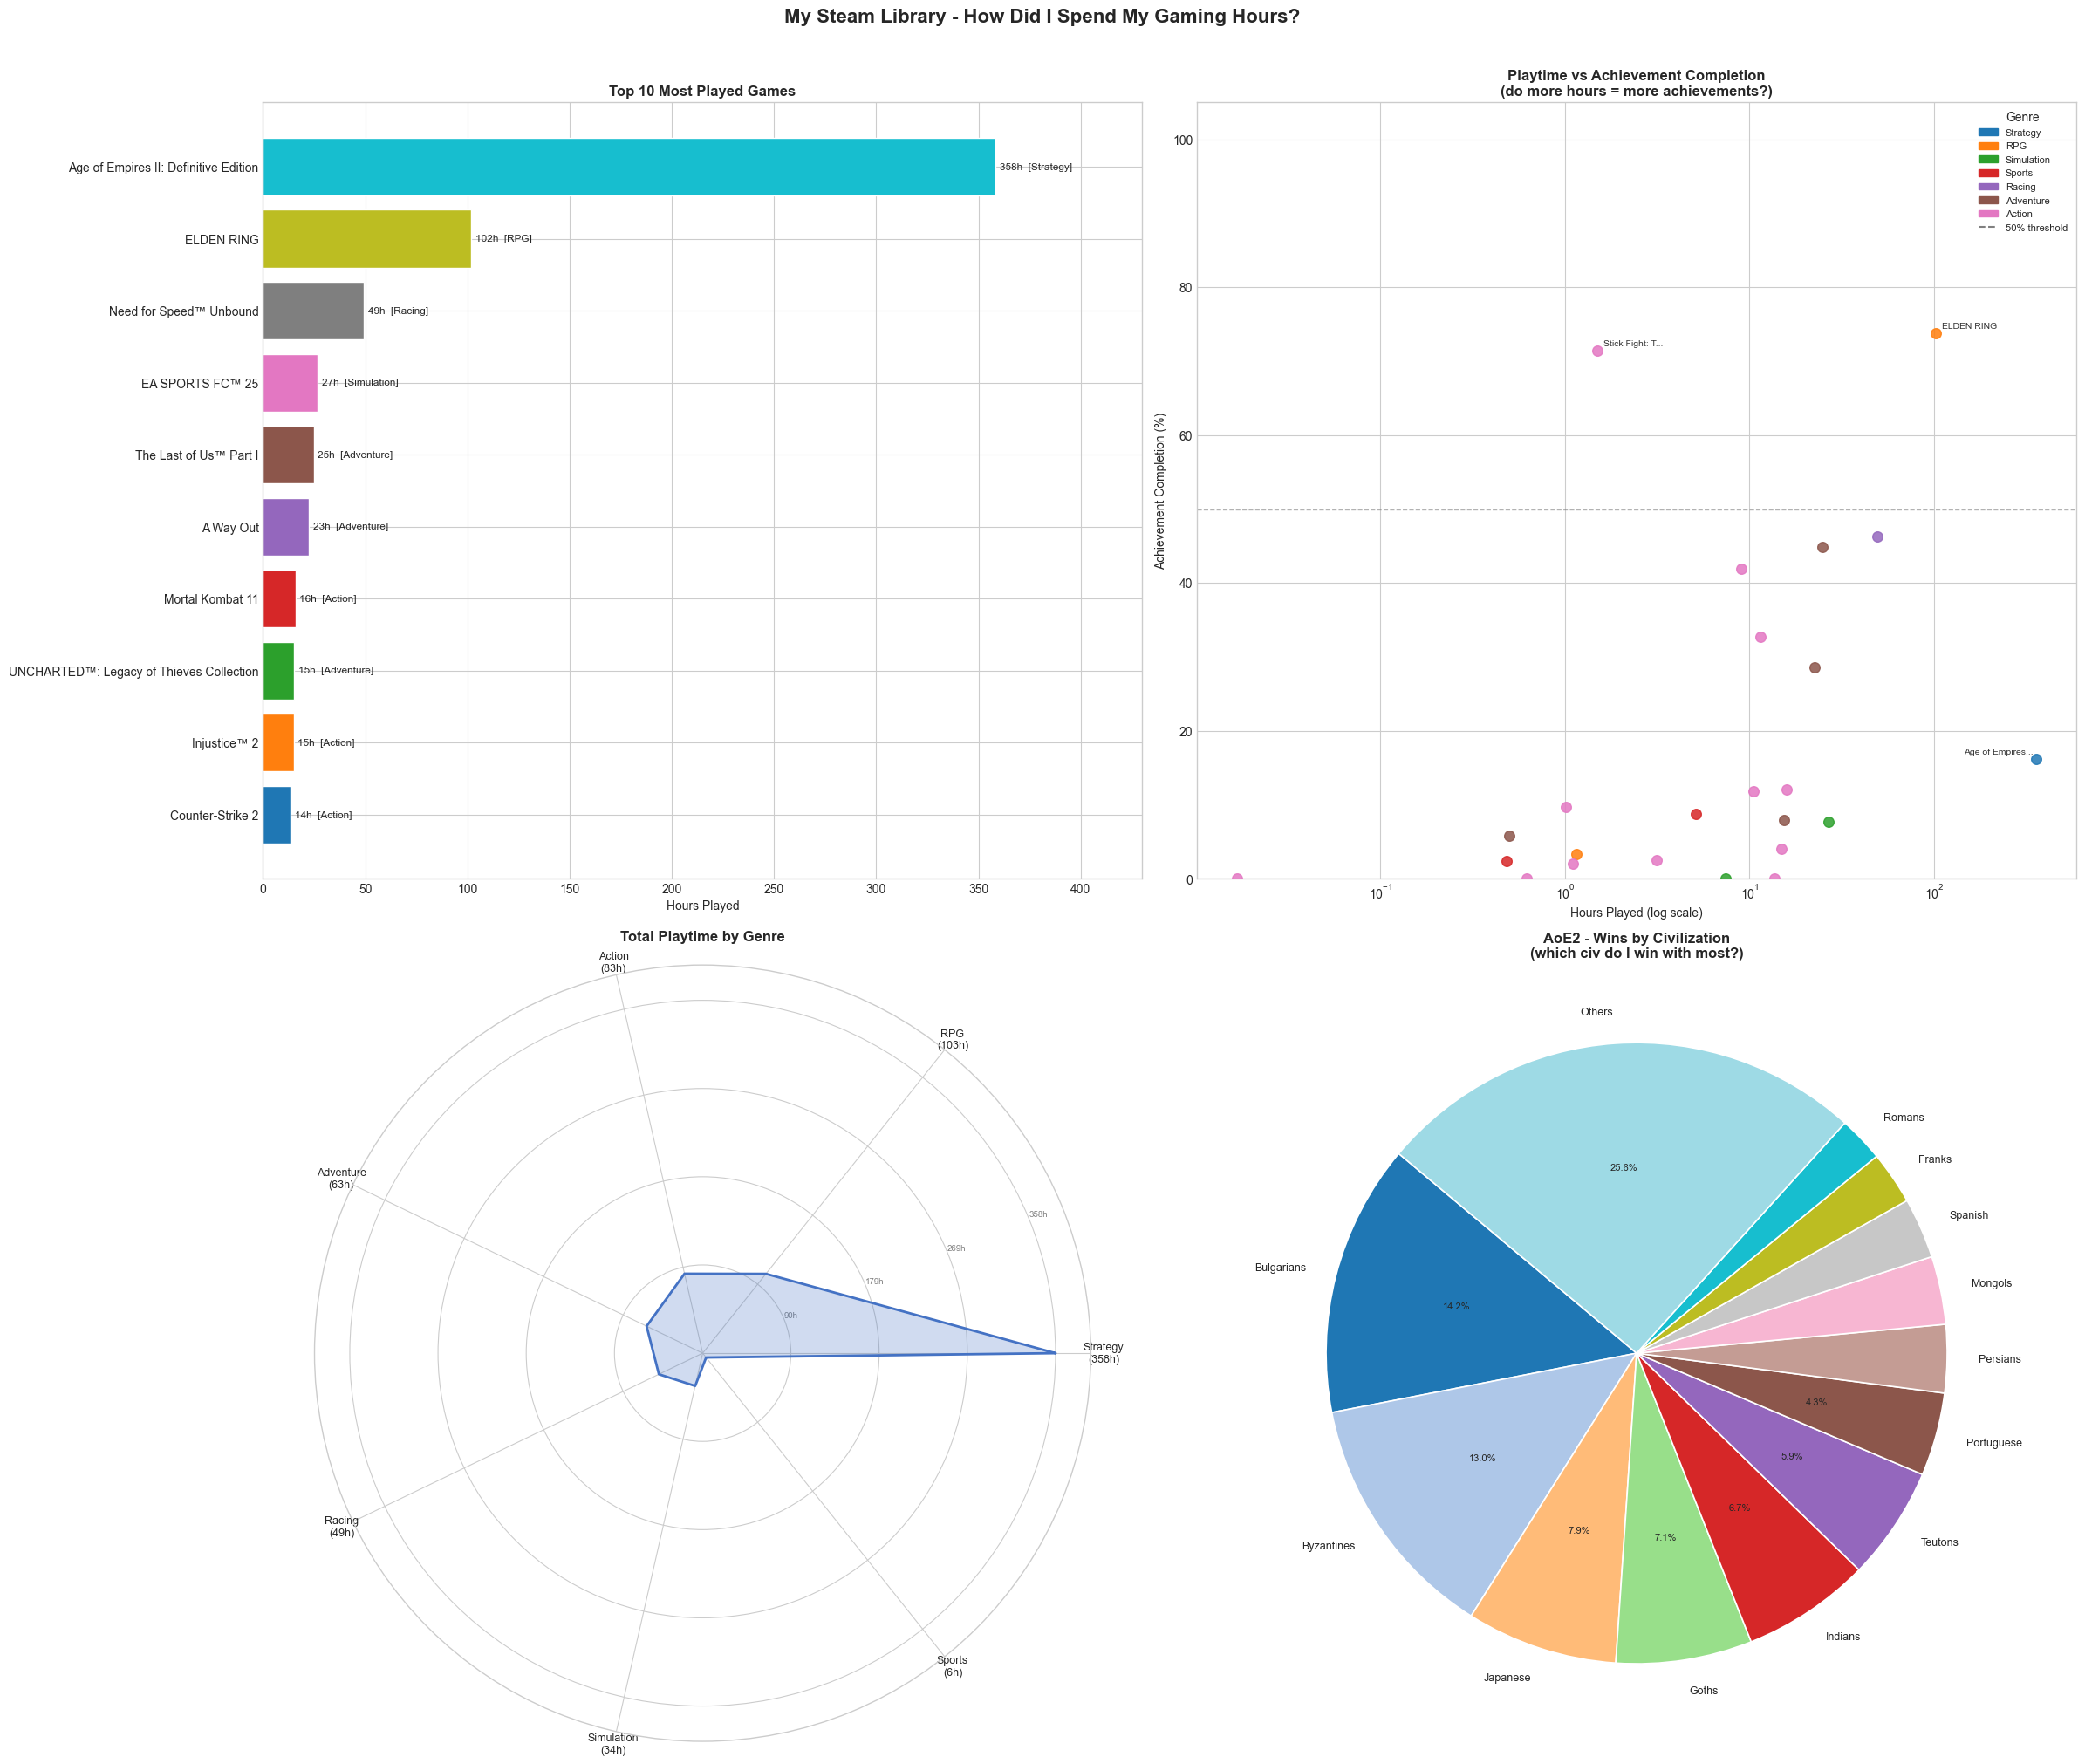

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def problem3():
    # Loads steam_data.json and aoe2_stats.json, then draws a 4-panel figure.
    # Panels: top 10 games bar, genre radar, playtime vs achievement scatter, AoE2 civ pie.

    raw = STEAM_DATA_RAW

    df = pd.DataFrame(raw)
    df['playtime_hours'] = df['playtime_forever'] / 60

    # Assign a single representative genre per game using priority order
    priority = ['Strategy', 'RPG', 'Simulation', 'Sports', 'Racing',
                'Adventure', 'Action', 'Indie', 'Casual', 'Free To Play', 'Unknown']

    def pick_genre(genres):
        for p in priority:
            if p in genres:
                return p
        return genres[0] if genres else 'Unknown'

    df['genre'] = df['genres'].apply(pick_genre)

    genre_list = ['Strategy', 'RPG', 'Simulation', 'Sports', 'Racing',
                  'Adventure', 'Action', 'Indie', 'Casual', 'Unknown']
    cmap = plt.cm.tab10
    genre_colors = {g: cmap(i / len(genre_list)) for i, g in enumerate(genre_list)}

    # Load AoE2 in-game stats from file fetched via Steam API
    aoe2_stats = {s['name']: s['value'] for s in AOE2_STATS_RAW}

    plt.style.use('seaborn-v0_8-whitegrid')
    fig = plt.figure(figsize=(24, 20))
    fig.suptitle("My Steam Library - How Did I Spend My Gaming Hours?",
                 fontsize=16, fontweight='bold', y=1.01)

    ax1 = fig.add_subplot(2, 2, 1)   # top-left:  bar chart
    ax3 = fig.add_subplot(2, 2, 2)   # top-right: scatter
    ax2 = fig.add_subplot(2, 2, 3)   # bot-left:  spider (polar)
    ax4 = fig.add_subplot(2, 2, 4)   # bot-right: pie chart

    # Panel 1: Horizontal bar chart - top 10 most played games
    top10 = df[df['playtime_hours'] > 0].nlargest(10, 'playtime_hours').sort_values('playtime_hours')
    # Give each bar a unique color to avoid same-genre bars looking identical
    bar_colors = [plt.cm.tab10(i / 10) for i in range(len(top10))]

    ax1.barh(top10['name'], top10['playtime_hours'], color=bar_colors, edgecolor='white')
    ax1.set_xlabel('Hours Played')
    ax1.set_title('Top 10 Most Played Games', fontweight='bold')

    # Annotate each bar with hours and genre
    for i, (val, genre) in enumerate(zip(top10['playtime_hours'], top10['genre'])):
        ax1.text(val + 2, i, f'{val:.0f}h  [{genre}]', va='center', fontsize=8.5)

    ax1.set_xlim(0, top10['playtime_hours'].max() * 1.2)

    # Panel 2: Radar (spider) chart - total playtime per genre
    genre_hours = df.groupby('genre')['playtime_hours'].sum()
    genre_hours = genre_hours[genre_hours > 0].sort_values(ascending=False)
    spider_genres = genre_hours.index.tolist()
    spider_values = genre_hours.values.tolist()

    N = len(spider_genres)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    # Close the polygon by repeating the first value
    values_closed = spider_values + [spider_values[0]]
    angles_closed = angles + [angles[0]]

    ax2.remove()
    ax2 = fig.add_subplot(2, 2, 3, polar=True)

    ax2.plot(angles_closed, values_closed, color='#4472C4', linewidth=2, zorder=3)
    ax2.fill(angles_closed, values_closed, color='#4472C4', alpha=0.25)

    ax2.set_xticks(angles)
    ax2.set_xticklabels(
        [f'{g}\n({h:.0f}h)' for g, h in zip(spider_genres, spider_values)],
        fontsize=9
    )

    max_val = max(spider_values)
    tick_vals = np.linspace(0, max_val, 5)[1:]
    ax2.set_yticks(tick_vals)
    ax2.set_yticklabels([f'{v:.0f}h' for v in tick_vals], fontsize=7, color='grey')
    ax2.set_ylim(0, max_val * 1.1)
    ax2.set_title('Total Playtime by Genre', fontweight='bold', pad=20)

    # Panel 3: Scatter plot - playtime (log scale) vs achievement completion %
    ach_data = []
    for _, row in df.iterrows():
        total = row.get('total_achievements', 0)
        unlocked = len(row['achievements'])
        if total > 0 and row['playtime_hours'] > 0:
            ach_data.append({
                'name': row['name'],
                'playtime_hours': row['playtime_hours'],
                'unlocked': unlocked,
                'total': total,
                'completion_pct': unlocked / total * 100,
                'genre': row['genre']
            })

    ach_df = pd.DataFrame(ach_data)

    # Plot each genre separately to get colored legend entries
    for genre in genre_list:
        sub = ach_df[ach_df['genre'] == genre]
        if sub.empty:
            continue
        ax3.scatter(sub['playtime_hours'], sub['completion_pct'],
                    color=genre_colors[genre], s=70, alpha=0.85, label=genre, zorder=3)

    # Label notable games (high completion or high playtime)
    for _, row in ach_df.iterrows():
        if row['completion_pct'] >= 70 or row['playtime_hours'] >= 50:
            short = row['name'] if len(row['name']) <= 16 else row['name'][:14] + '...'
            xoff = -60 if row['playtime_hours'] >= 300 else 5
            ax3.annotate(short, xy=(row['playtime_hours'], row['completion_pct']),
                         xytext=(xoff, 4), textcoords='offset points',
                         fontsize=7.5, color='#333333')

    ax3.set_xscale('log')
    ax3.set_xlabel('Hours Played (log scale)')
    ax3.set_ylabel('Achievement Completion (%)')
    ax3.set_title('Playtime vs Achievement Completion\n(do more hours = more achievements?)',
                  fontweight='bold')
    ax3.set_ylim(0, 105)
    ax3.axhline(y=50, color='grey', linestyle='--', linewidth=1, alpha=0.6)

    handles3 = [mpatches.Patch(color=genre_colors[g], label=g)
                for g in genre_list if g in ach_df['genre'].values]
    handles3.append(plt.Line2D([0], [0], color='grey', linestyle='--', label='50% threshold'))
    ax3.legend(handles=handles3, title='Genre', fontsize=8, loc='upper right')

    # Panel 4: Pie chart - AoE2 wins by civilization (top 12 + others grouped)
    vic = {k.replace('STAT_VICTORY_', '').title(): v
           for k, v in aoe2_stats.items()
           if k.startswith('STAT_VICTORY_') and k != 'STAT_VICTORY_RANDOM'}
    vic_series = pd.Series(vic).sort_values(ascending=False)

    top12 = vic_series.head(12)
    others_val = vic_series.iloc[12:].sum()
    pie_data = pd.concat([top12, pd.Series({'Others': others_val})])

    # Use tab20 for enough distinct slice colors
    pie_colors = plt.cm.tab20(np.linspace(0, 1, len(pie_data)))

    wedges, texts, autotexts = ax4.pie(
        pie_data.values,
        labels=pie_data.index,
        colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%' if p >= 4 else '',
        startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=1.2)
    )
    for t in texts:
        t.set_fontsize(9)
    for at in autotexts:
        at.set_fontsize(8)

    ax4.set_title('AoE2 - Wins by Civilization\n(which civ do I win with most?)',
                  fontweight='bold')

    plt.tight_layout()
    plt.show()


problem3()